# Exercises to Statistical Methods and Analysis Techniques in Experimental Physics
## Exercise 6, April 1st, 2025

### 1. F-Test

You are given data about bacterial growth and would like to fit the data. You try a simpler and a more complicated model and would like to know which model fits best the data.

Exponential model: $N=Ae^{at}$

Power law model: $N = Bt^b$

a. Fit the data using the two different models and plot the results with the uncertainties.

b. Decide which model fits the data the best using the F-test

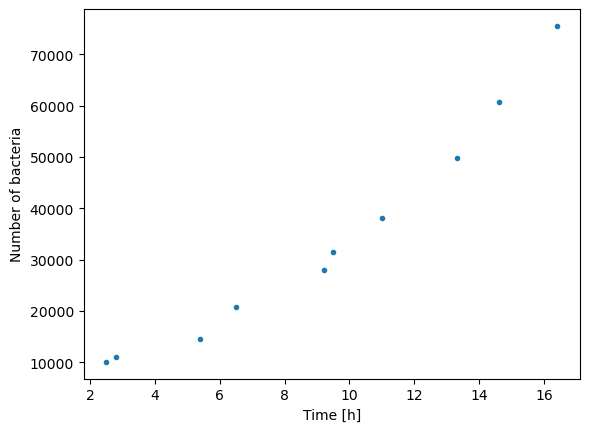

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from dataclasses import dataclass
from autograd import hessian, grad
import seaborn as sns
from scipy.stats import f

T = np.array([2.5, 2.8, 5.4, 6.5, 9.2, 9.5, 11.0, 13.3, 14.6, 16.4]) #in hours
N = np.array([10.07, 11.07, 14.59, 20.70, 27.94, 31.50, 38.04, 49.90, 60.72, 75.57]) #x10^3

plt.plot(T, N*1e3, '.')
plt.xlabel('Time [h]')
plt.ylabel('Number of bacteria')
plt.show()


In [12]:
# a.
def exp_model(t, params):
    A, a = params
    return A*np.e**(a*t)

def pow_model(t, params):
    B, b = params
    return B*t**b

In [13]:
@dataclass
class get_NLL:
    x_data: np.array
    y_data: np.array
    model: callable

    def __call__(self, params):
        '''Assuming that the number of bateria is gaussian distributed around the value predicted by the model
        with equal std cause we are not provided with the uncertainty on the data'''
        
        NLL = 0
        for x, y in np.column_stack((self.x_data, self.y_data)):
            NLL += (y-self.model(x, params))**2
        
        return NLL

@dataclass
class fit:
    x_data: np.array
    y_data: np.array
    model: callable

    def __post_init__(self):
        self.NLL = get_NLL(x_data = self.x_data,
                           y_data = self.y_data,
                           model  = self.model)

    def __call__(self, initial_params, bounds):
        optimization_results = minimize(self.NLL,
                                        initial_params,
                                        bounds=bounds)
        return optimization_results

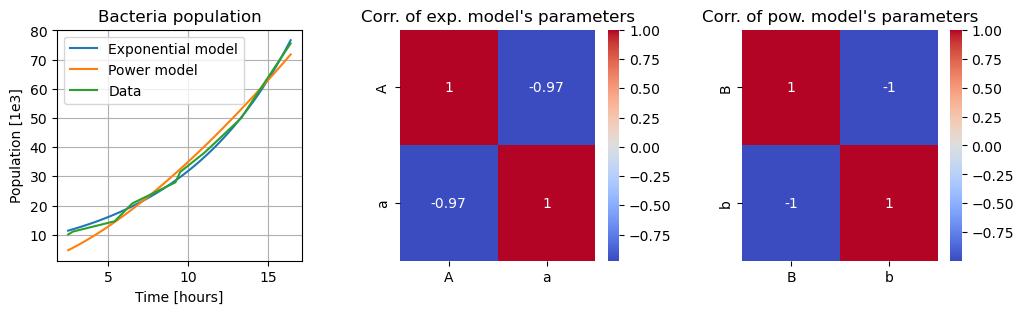

Exponential model N=Ae^(a*t) optimal parameters:
      A =  8.082  pm  0.197
      a =  0.137  pm  0.002


Power law model N=Bt^b optimal parameters:
      B =  1.237  pm  0.076
      b =  1.452  pm  0.024


In [15]:
# Fitting the exponential model
fit_exp = fit(x_data = T,
              y_data = N,
              model  = exp_model)

initial_params = [1,1]
bounds = [[1e-6, np.inf],
          [0, np.inf]]
opt_exp_model = fit_exp(initial_params = initial_params,
                        bounds         = bounds)
hess = hessian(get_NLL(x_data = T, y_data = N, model = exp_model))(opt_exp_model.x)
cov_matrix = np.linalg.pinv(hess)
exp_model_param_unc   = np.sqrt(cov_matrix.diagonal())
exp_model_corr_matrix = cov_matrix/np.outer(exp_model_param_unc, exp_model_param_unc)

# Fitting the power model
fit_pow = fit(x_data = T,
              y_data = N,
              model  = pow_model)

initial_params = [1,1]
bounds = [[1e-6, np.inf],
          [0, np.inf]]
opt_pow_model = fit_pow(initial_params = initial_params,
                        bounds         = bounds)
hess = hessian(get_NLL(x_data = T, y_data = N, model = pow_model))(opt_pow_model.x)
cov_matrix = np.linalg.pinv(hess)
pow_model_param_unc   = np.sqrt(cov_matrix.diagonal())
pow_model_corr_matrix = cov_matrix/np.outer(pow_model_param_unc, pow_model_param_unc)

# Plotting
fig, axes = plt.subplots(1,3,figsize=[12,3])
fig.subplots_adjust(wspace=0.4)

ax = axes[0]
ax.grid(1)
x = np.linspace(min(T), max(T))
y = exp_model(x, opt_exp_model.x)
ax.plot(x,y, label='Exponential model')
x = np.linspace(min(T), max(T))
y = pow_model(x, opt_pow_model.x)
ax.plot(x,y, label='Power model')
ax.plot(T,N, label='Data')
ax.legend()
ax.set_xlabel('Time [hours]')
ax.set_ylabel('Population [1e3]')
ax.set_title('Bacteria population')

ax = axes[1]
sns.heatmap(exp_model_corr_matrix, ax=ax, annot=True, cmap='coolwarm', xticklabels=['A','a'], yticklabels=['A','a'])
ax.set_title("Corr. of exp. model's parameters")

ax = axes[2]
sns.heatmap(pow_model_corr_matrix, ax=ax, annot=True, cmap='coolwarm', xticklabels=['B','b'], yticklabels=['B','b'])
ax.set_title("Corr. of pow. model's parameters")
plt.show()

# Printing
print('Exponential model N=Ae^(a*t) optimal parameters:')
print('A = '.rjust(10),f'{opt_exp_model.x[0]:.3f}'," pm ",f'{exp_model_param_unc[0]:.3f}')
print('a = '.rjust(10),f'{opt_exp_model.x[1]:.3f}'," pm ",f'{exp_model_param_unc[1]:.3f}')

print('\n')

print('Power law model N=Bt^b optimal parameters:')
print('B = '.rjust(10),f'{opt_pow_model.x[0]:.3f}'," pm ",f'{pow_model_param_unc[0]:.3f}')
print('b = '.rjust(10),f'{opt_pow_model.x[1]:.3f}'," pm ",f'{pow_model_param_unc[1]:.3f}')

In [36]:
# b.
# The F-value is the ratio of the two normalized chi-squared. In order to obatin them, I'll define the following function
from typing import Optional

@dataclass
class get_norm_chi2:
    x_data:  np.array
    y_data:  np.array
    x_error: Optional[np.array] = None
    y_error: Optional[np.array] = None

    def __post_init__(self):
        # Defining x_errors if they are not provided
        try:
            if self.x_error == None:
                self.x_error = np.zeros(np.shape(self.x_data))
        except ValueError:
            pass

        # Defining y_errors if they are not provided
        try:
            if self.y_error == None:
                self.y_error = np.ones(np.shape(self.y_data)) # They are needed so I arbitrarily assign 1 to all
        except ValueError:
            pass

    def __call__(self, model, params):
        ndof = len(self.x_data)-len(params)
        chi2 = 0
        for i,x in enumerate(self.x_data):
            y = self.y_data[i]
            var = self.y_error[i]**2 + (grad(model)(x, params=params))**2*self.x_error[i]**2
            chi2 += (y-model(x, params))**2/var

        return chi2/ndof

In [24]:
norm_chi2 = get_norm_chi2(x_data = T,
                          y_data = N)
exp_norm_chi2 = norm_chi2(exp_model,opt_exp_model.x)
pow_norm_chi2 = norm_chi2(pow_model,opt_pow_model.x)
F = exp_norm_chi2/pow_norm_chi2# if exp_norm_chi2>pow_norm_chi2 else pow_norm_chi2/exp_norm_chi2

ndof = len(T)-2
p_value = 1-f.cdf(F, ndof, ndof)
print(f'Given the p-value of {p_value:.3f} for the F-test=chi2_exp/chi2_pow, we conclude that the exponential model \
describes the data in a more satisfactory way than the power-law model.')

NameError: name 'get_norm_chi2' is not defined

### 2. ANOVA test

In your lab, you are testing 2 new treatments on mice and would like to know if any of them is really efficient. To do so, you check the survival time of three groups of mice: the first group recieved the first treatment, the second group the second treatment and the third group is kept as control group. Test at 99% significance whether the results of this experiment show the efficacy of any of the treatment.

In [3]:
import numpy as np
from scipy.stats import f, t

#survival time in days
group_1 = np.array([71, 72, 75, 80, 60, 65, 63, 78, 75, 73, 72, 65, 63, 69, 64, 71])
group_2 = np.array([77, 67, 79, 78, 81, 72, 71, 84, 91])
group_3 = np.array([81, 79, 73, 71, 75, 84, 77, 67])

In [17]:
def ANOVA_test(groups):
    all_data = np.concatenate(groups)
    
    var_w = 0 # variance within the groups
    for g in groups:
        mean_g = np.sum(g)/len(g)
        var_w += np.sum( (g-mean_g)**2/(len(all_data)-len(groups)) )
    
    var_b = 0 # variance between groups
    mean_all = np.sum(all_data)/len(all_data)
    for g in groups:
        mean_g = np.sum(g)/len(g)
        var_b += len(g)*(mean_g-mean_all)**2/(len(groups)-1)
    
    F = var_b/var_w
    ndof_numerator   = len(groups)-1
    ndof_denominator = len(all_data)-len(groups)
    p_value = 1-f.cdf(F, ndof_numerator, ndof_denominator)
    print(f'Given the p-value of {p_value:.3f} for the F-test of the ANOVA method, we conclude that the results of the \
{len(groups)} groups compatible with each-other choosing a significance level of {(1-p_value)*100:.2f}%')

In [18]:
# The treatment is supposed to elongate the mice's lives (I assume) so the hypothesis we want to test is whether the
# first or second group lived equally long as or longer than the third control group. First we see if there's any
# difference at all by checking wheter the three samples are compatible.

groups   = [group_1, group_2, group_3]
ANOVA_test(groups)
print('Since we have chosen a significance level of 99%, lower than the one required to accept the hypothesis that \
they are compatible, we must conclude that the three samples are not compatible with 99% significance level.')

Given the p-value of 0.008 for the F-test of the ANOVA method, we conclude that the results of the 3 groups compatible with each-other choosing a significance level of 99.17%
Since we have chosen a significance level of 99%, lower than the one required to accept the hypothesis that they are compatible, we must conclude that the three samples are not compatible with 99% significance level.


In [27]:
# Since the ANOVA test highlighted that the three samples are not compatible with a significance level above 99%, it is
# worth studying the pair-wise compatibility of the first two samples with the third, "control" one.

# Compatibility 1-3
groups = [group_1, group_3]
ANOVA_test(groups)
print('Since we have chosen a significance level of 99%, higher than the one required to accept the hypothesis that \
they are compatible, we must conclude that the first and the third sample are compatible with 99% significance level.')
print('\n')

# Compatibility 2-3
groups = [group_2, group_3]
ANOVA_test(groups)
print('Since we have chosen a significance level of 99%, higher than the one required to accept the hypothesis that \
they are compatible, we must conclude that the second and the third sample are compatible with 99% significance level.')
print('\n')

# Compatibility 1-2
groups = [group_1, group_2]
ANOVA_test(groups)
print('Since we have chosen a significance level of 99%, lower than the one required to accept the hypothesis that \
they are compatible, we must conclude that the first and the second sample are not compatible with 99% significance level.')

Given the p-value of 0.023 for the F-test of the ANOVA method, we conclude that the results of the 2 groups compatible with each-other choosing a significance level of 97.74%
Since we have chosen a significance level of 99%, higher than the one required to accept the hypothesis that they are compatible, we must conclude that the first and the third sample are compatible with 99% significance level.


Given the p-value of 0.557 for the F-test of the ANOVA method, we conclude that the results of the 2 groups compatible with each-other choosing a significance level of 44.33%
Since we have chosen a significance level of 99%, higher than the one required to accept the hypothesis that they are compatible, we must conclude that the second and the third sample are compatible with 99% significance level.


Given the p-value of 0.006 for the F-test of the ANOVA method, we conclude that the results of the 2 groups compatible with each-other choosing a significance level of 99.38%
Since we have ch

### 3.  Jackknife and Bootstrap

Compute the value of $cos(\langle x \rangle)$ for $x_i = \pi/3 + \epsilon_i$ where $\epsilon_i$ is a random variable with a Gaussian distribution with unit variance and mean centered around zero. First compute the value of the function using $N = 1000$ points and then compare your results when using

a. the jackknife method

b. the bootstrap method with $N_\text{boot} = 100$.

### 4. Kullback-Leibler Divergence
You are given two sample distributions P and Q. 

a. Compute the Kullback-Leibler divergence $D_{KL}(P,Q)$ and $D_{KL}{Q,P}$.

b. Now suppose the data is smoothed by introducing a small constant ϵ. Compute the Kullback-Leibler divergence $D_{KL}(Ps,Qs)$ and $D_{KL}{Qs,Ps}$.

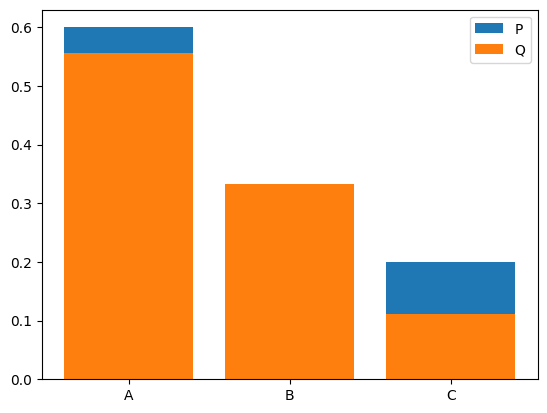

In [ ]:
P = np.array([3/5, 1/5, 1/5])
Q = np.array([5/9, 3/9, 1/9])

eps = 1e-2
Ps = P - eps/3
Qs = Q - eps/3

x = ['A', 'B', 'C']
plt.bar(x, P, label = 'P')
plt.bar(x, Q, label = 'Q')
plt.legend()
plt.show()